## Goal

Understand why the selected model makes its predictions rather than only evaluating its performance.

## Research Notes

1) Why is model explainability important in machine learning projects?
2) Is a highly accurate model always useful if we cannot explain its predictions? Why or why not?
3) What is the difference between Feature Importance and SHAP values?
4) Why are SHAP values considered local explanations while traditional feature importance provides a global explanation?
5) Suppose your model predicts that a customer will churn. How could SHAP help explain this prediction to the business team?
6) Imagine your model achieves excellent predictive performance, but the business stakeholders do not trust its decisions. How would explainability improve confidence in the model and support its deployment?

---

- 1-Model explainability is important because it helps people understand, trust, and validate the model's predictions. It also supports debugging, fairness, and better decision-making.

- 2-No. A highly accurate model is not always useful if its predictions cannot be explained, because stakeholders may not trust it, and it is difficult to detect errors, bias, or make informed decisions.

- 3-Feature Importance measures the overall importance of each feature in the model, while SHAP values explain how each feature contributes to an individual prediction, including both the magnitude and direction of its impact.

- 4-SHAP values provide local explanations because they explain the contribution of each feature to a single prediction. In contrast, Feature Importance provides a global explanation by measuring the overall importance of each feature across the entire model.

- 5-SHAP explains which features contributed to the churn prediction and how much each feature increased or decreased the predicted risk. This helps the business team understand the reason behind the prediction and make better retention decisions.

- 6-Explainability makes the model's decisions transparent by showing why predictions are made and which features influence them. This builds trust, helps detect potential bias or errors, and gives stakeholders greater confidence to deploy the model in real-world applications.

In [84]:
# Imports 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
import shap
import joblib

In [2]:
# Load Clean Dataset
df = pd.read_csv('../data/processed/customer_churn_clean.csv')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Feature & Target Separation
X = df.drop(columns='Churn')
y = df['Churn'].map({"No": 0, "Yes": 1})

In [4]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.3, random_state=42, stratify=y)

In [5]:
# Feature Lists
binary_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

multiclass_features = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

passthrough_features = [
    "SeniorCitizen"
]

In [6]:
# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            'binary',
            OrdinalEncoder(),
            binary_features
        ),
        (
            'multiclass',
            OneHotEncoder(handle_unknown='ignore'),
            multiclass_features
        ),
        (
            'numerical',
            StandardScaler(),
            numerical_features
        ),
        (
            'pass',
            'passthrough',
            passthrough_features
        )
    ]
)

In [7]:
# Building best model pipeline
tuned_logistic_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('tuned_log', LogisticRegression(C=1, penalty='l2', solver='lbfgs', random_state=42))
])

In [8]:
tuned_logistic_pipe.fit(X_train, y_train)

C:\Users\User\anaconda3\envs\deploy\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('tuned_log', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('binary', ...), ('multiclass', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specify

In [85]:
joblib.dump(tuned_logistic_pipe, '../models/logistic_regression_pipeline.joblib')

['../models/logistic_regression_pipeline.joblib']

In [9]:
# Extract coefficients
log_model = tuned_logistic_pipe.named_steps['tuned_log']

In [10]:
coefficients = log_model.coef_[0]

In [11]:
# Extract feature names
preprocessor = tuned_logistic_pipe.named_steps['preprocessor']

In [12]:
feature_names = preprocessor.get_feature_names_out()

In [22]:
# Build DataFrame and Sort
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    'AbsCoefficient': np.abs(coefficients)
}).sort_values(by='AbsCoefficient', ascending=False, ignore_index=True)

In [23]:
feature_importance_df["Direction"] = np.where(
    feature_importance_df["Coefficient"] > 0,
    "Increase Churn",
    "Decrease Churn"
)

In [24]:
feature_importance_df

,Feature,Coefficient,AbsCoefficient,Direction
0,numerical__tenure,-1.463266,1.463266,Decrease Churn
1,multiclass__Contract_Two year,-0.781850,0.781850,Decrease Churn
2,numerical__TotalCharges,0.750143,0.750143,Increase Churn
3,multiclass__InternetService_DSL,-0.622276,0.622276,Decrease Churn
4,multiclass__Contract_Month-to-month,0.520715,0.520715,Increase Churn
5,multiclass__InternetService_Fiber optic,0.507116,0.507116,Increase Churn
6,numerical__MonthlyCharges,-0.484446,0.484446,Decrease Churn
7,binary__PaperlessBilling,0.322301,0.322301,Increase Churn
8,multiclass__OnlineBackup_No internet service,-0.319248,0.319248,Decrease Churn
9,multiclass__StreamingMovies_No internet service,-0.319248,0.319248,Decrease Churn


In [40]:
feature_importance_df["Feature"] = (
    feature_importance_df["Feature"]
    .str.replace("numerical__", "", regex=False)
    .str.replace("binary__", "", regex=False)
    .str.replace("multiclass__", "", regex=False)
    .str.replace("pass__", "", regex=False)
    .str.replace("_", " ")
)

In [41]:
feature_importance_df["Feature"] = (
    feature_importance_df["Feature"]
    .str.replace("Month-to-month", "Month-to-Month Contract")
    .str.replace("Two year", "Two-Year Contract")
    .str.replace("Electronic check", "Electronic Check")
    .str.replace("PaperlessBilling", "Paperless Billing")
    .str.replace("InternetService", "Internet Service")
)

In [42]:
# Top Positive
top_positives = (
    feature_importance_df
    .query("Coefficient > 0")
    .sort_values("Coefficient", ascending=False)
    .head(10)
)

In [46]:
# Top Negative
top_negatives = (
    feature_importance_df
    .query("Coefficient < 0")
    .sort_values("Coefficient")
)
top_negatives = top_negatives[
    ~top_negatives["Feature"].str.contains("No internet service")
].head(10)

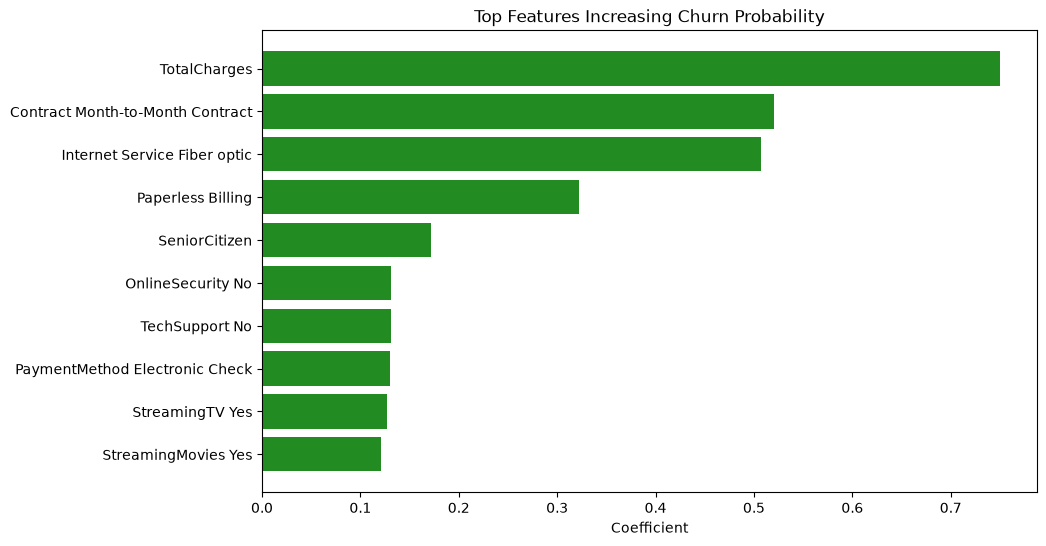

In [75]:
# Plot 1 
plt.figure(figsize=(10,6))

plt.barh(
    top_positives["Feature"],
    top_positives["Coefficient"],
    color="forestgreen"
)

plt.xlabel("Coefficient")
plt.title("Top Features Increasing Churn Probability")

plt.gca().invert_yaxis()

plt.savefig(
    "../figures/Sprint10/logistic_positive_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

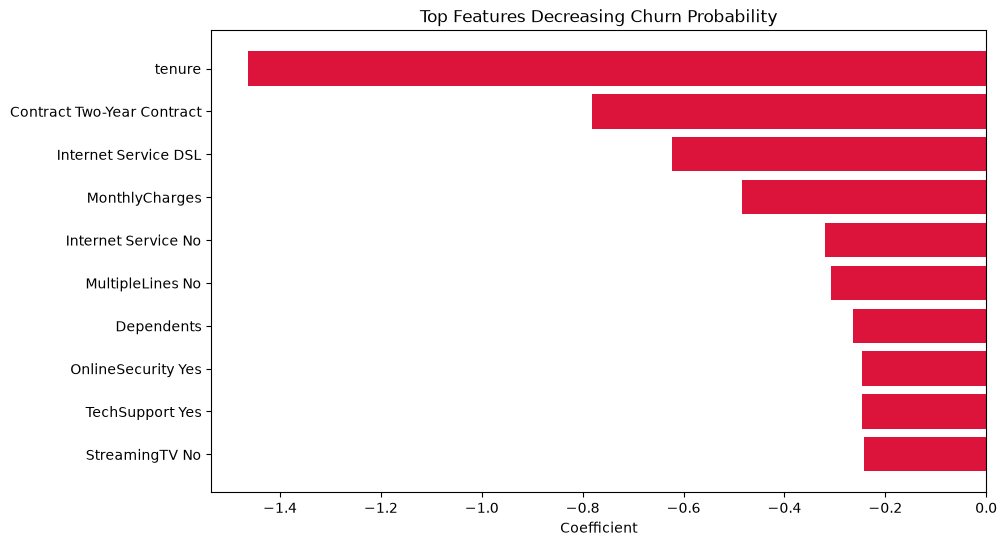

In [76]:
# plot 2
plt.figure(figsize=(10,6))

plt.barh(
    top_negatives["Feature"],
    top_negatives["Coefficient"],
    color="crimson"
)

plt.xlabel("Coefficient")
plt.title("Top Features Decreasing Churn Probability")

plt.gca().invert_yaxis()

plt.savefig(
    "../figures/Sprint10/logistic_negative_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
# Calculate Permutation Importance
perm = permutation_importance(
    estimator=tuned_logistic_pipe,
    X=X_test,
    y=y_test,
    scoring="recall",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

In [62]:
# Create a DataFrame
data = {
    'Features': df.columns[:-1],
    'Importance': perm.importances_mean
}
df_permutation_importance = pd.DataFrame(data).sort_values('Importance',ascending=False).reset_index(drop=True)

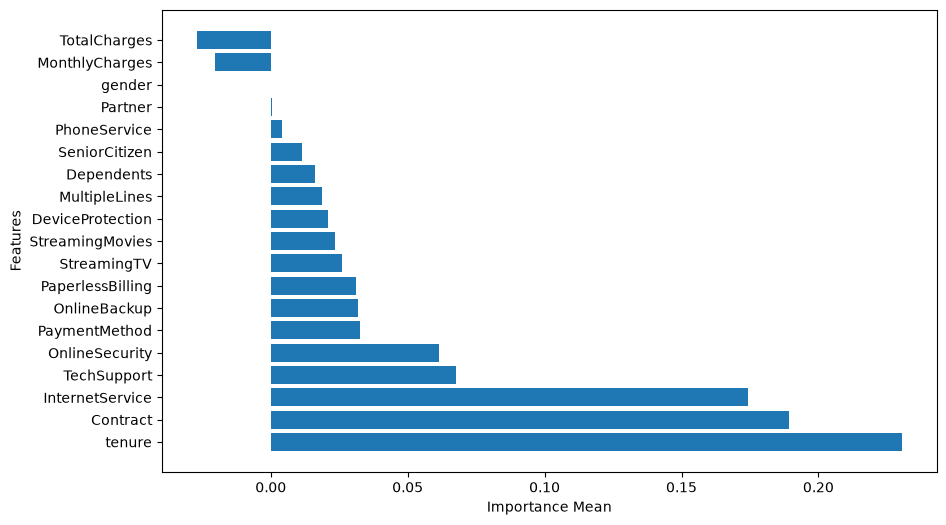

In [77]:
# Visualization
plt.figure(figsize=(10, 6))
plt.barh(df_permutation_importance['Features'], df_permutation_importance['Importance'])
plt.xlabel('Importance Mean')
plt.ylabel('Features')
plt.savefig(
    "../figures/Sprint10/permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [70]:
X_train_processed = preprocessor.transform(X_train)

background = shap.sample(X_train_processed, 100, random_state=42)

explainer = shap.Explainer(
    log_model,
    background
)
X_test_processed = preprocessor.transform(X_test)

In [71]:
# SHAP
shap_values = explainer(X_test_processed)

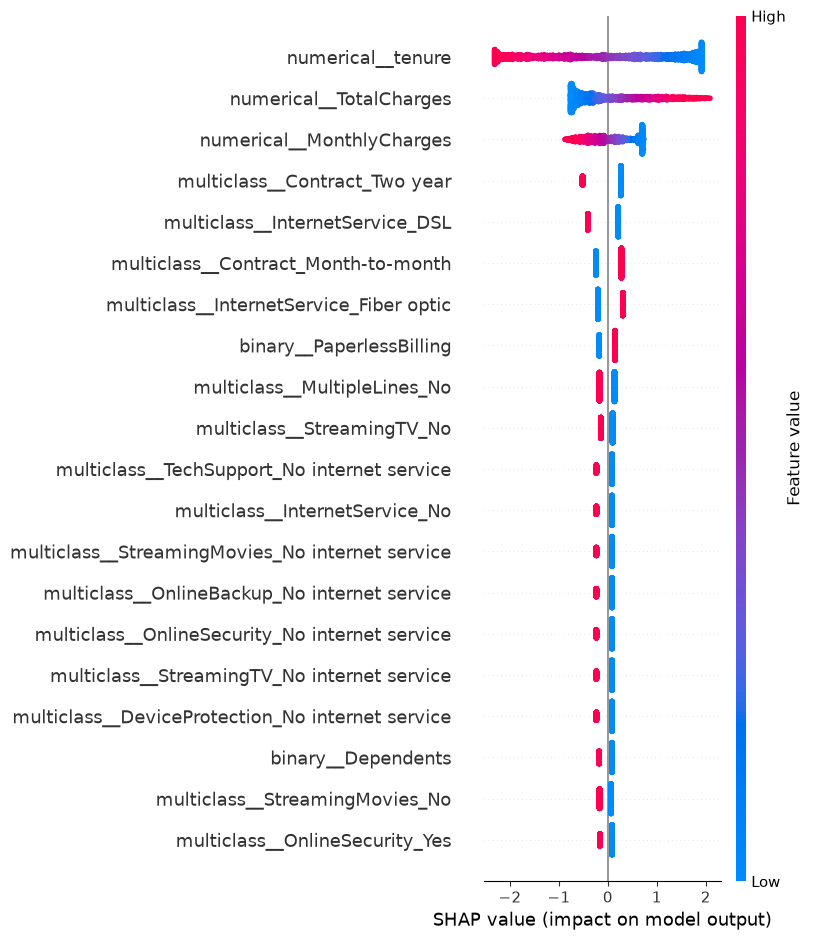

<Figure size 640x480 with 0 Axes>

In [78]:
# Summary Plot
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)
plt.tight_layout()
plt.savefig(
    "../figures/Sprint10/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

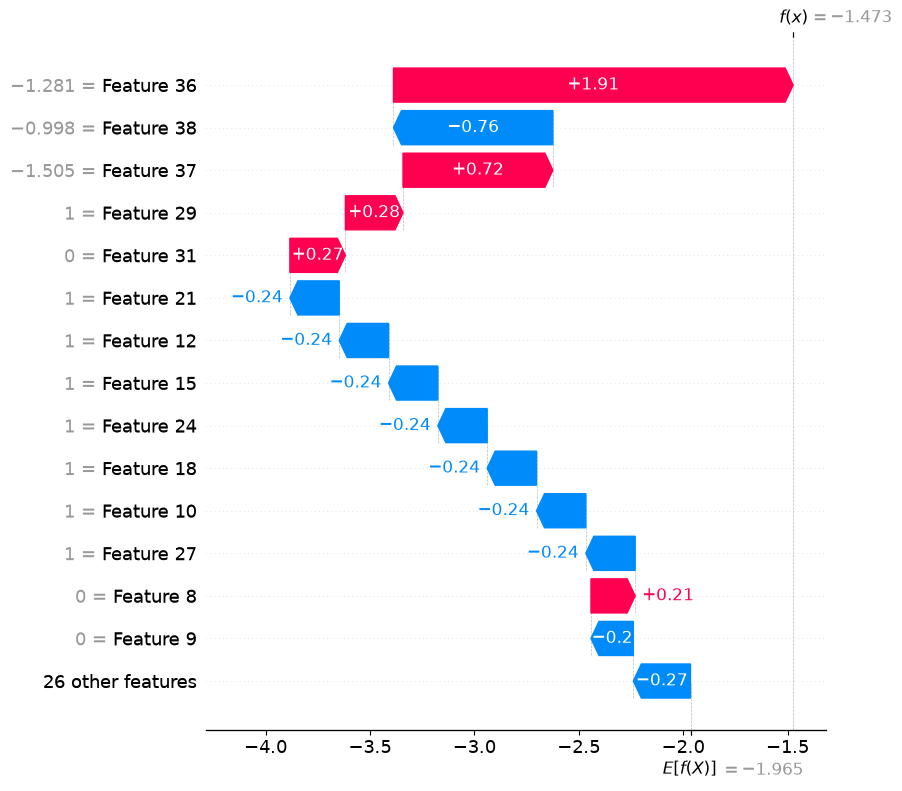

<Figure size 640x480 with 0 Axes>

In [79]:
# Waterfall Plot
sample_idx = 0
shap.waterfall_plot(
    shap_values[sample_idx],
    max_display=15
)
plt.tight_layout()
plt.savefig(
    "../figures/Sprint10/shap_waterfall_example.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [83]:
# Force Plot
force = shap.force_plot(
    explainer.expected_value,
    shap_values.values[sample_idx],
    X_test_processed[sample_idx],
    feature_names=feature_names
)

shap.save_html(
    "../figures/Sprint10/shap_force_plot.html",
    force
)

## Engineering Analysis

This Sprint focused on improving model interpretability by analyzing feature importance from multiple perspectives.

For Logistic Regression, the learned coefficients provided a global interpretation of how each feature influences churn prediction.

Positive coefficients increased the likelihood of customer churn, while negative coefficients reduced it.

The strongest positive contributors included:

- Month-to-month contracts
- Fiber optic internet service
- Paperless billing

These features were associated with a higher probability of churn.

Conversely, the strongest negative contributors included:

- Longer customer tenure
- Two-year contracts
- DSL internet service

These variables consistently reduced churn probability, indicating stronger customer retention.

To complement coefficient analysis, Permutation Importance was applied.

Unlike model coefficients, permutation importance measures how prediction performance changes when each feature is randomly shuffled.

The results confirmed that tenure, contract type, and internet service remain the most influential variables, providing additional confidence that these features genuinely drive model performance rather than simply receiving large coefficients.

Finally, SHAP analysis was performed to obtain local explanations for individual predictions.

SHAP demonstrated how each feature contributed positively or negatively for a specific customer while also providing a global summary across the entire dataset.

The SHAP Summary Plot highlighted the overall importance and direction of feature effects, whereas the Waterfall and Force plots explained individual customer predictions step by step.

Combining Logistic Regression coefficients, Permutation Importance, and SHAP produced a much more comprehensive understanding of the model.

Instead of relying solely on predictive metrics, the project now provides transparent explanations that can support business decision-making and increase stakeholder trust in the deployed model.

## Key Findings

- Logistic Regression remained highly interpretable while maintaining the strongest overall performance.
- Customer tenure was consistently identified as one of the most influential churn predictors.
- Long-term contracts significantly decreased churn probability.
- Month-to-month contracts substantially increased churn risk.
- Fiber optic internet service showed a positive association with churn.
- Permutation Importance confirmed the importance of key business features identified by model coefficients.
- SHAP successfully explained individual customer predictions while also providing a global interpretation of feature behavior.
- Combining multiple explainability techniques produced more reliable insights than relying on a single method.
- Model explainability is essential for increasing stakeholder confidence and supporting production deployment.

## Sprint Retrospective

This Sprint introduced practical model explainability techniques beyond traditional performance evaluation.

Logistic Regression coefficients provided an initial understanding of feature influence, but they alone were insufficient for explaining individual predictions.

Permutation Importance offered a model-agnostic validation of feature relevance by measuring the impact of feature shuffling on predictive performance.

SHAP further extended interpretability by explaining how each feature contributed to specific customer predictions, enabling both global and local explanations.

One important lesson learned during this Sprint was that explainability and predictive performance should complement each other.

A model with strong predictive metrics becomes considerably more valuable when its decisions can also be understood and justified.

The project has now progressed from simply selecting the best-performing model toward understanding why that model makes its predictions, bringing it closer to real-world machine learning deployment.